# QPUF Test – 1-Qubit Haar Random Unitary, Two-Stage QPE

**Protocol (mid-circuit measurement, Qiskit)**

| | Stage 1 | Stage 2 |
|--|--|--|
| Precision qubits | `prec1` (n_prec) | `prec2` (n_prec) |
| Target qubit | shared (1 qubit) | same, after collapse |
| Measurement | mid-circuit → `c1` | final → `c2` |

The 1-qubit Haar-random unitary U is generated via ZYZ Euler decomposition and expressed as a 2×2 matrix for use in Qiskit's `UnitaryGate`.

**Sections**
- **A** Local simulation (AerSimulator) — verify the protocol  
- **B** Cost estimation — transpile to IQM native gates, estimate AWS bill  
- **C** Run on IQM Garnet (AWS) — submit via `qiskit-braket-provider`

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import QFTGate
from qiskit_aer import AerSimulator

# Amazon Braket (hardware section)
from braket.aws import AwsDevice, AwsSession
from braket.circuits import Circuit

## Helper Functions

In [2]:
def haar_random_1qubit_Ugate(circuit: Circuit, qubit: int, rng=None) -> Circuit:
    """
    Appends a Haar-random 1-qubit unitary to `qubit` in `circuit`
    using ZYZ Euler decomposition: U = Rz(phi) Ry(theta) Rz(lam)

    Sampling from the Haar measure on U(2):
      - phi, lam ~ Uniform[0, 2*pi)
      - theta    = 2 * arccos(sqrt(u)),  u ~ Uniform[0, 1]
        (ensures cos^2(theta/2) is uniform, giving the correct Haar measure)

    The global phase e^{i*alpha} is physically unobservable and is dropped.

    Args:
        circuit : Braket Circuit to append gates to
        qubit   : target qubit index
        rng     : np.random.Generator (optional, for reproducibility)

    Returns:
        The same circuit object, mutated in place
    """
    if rng is None:
        rng = np.random.default_rng()

    # Sample Euler angles from the Haar measure on U(2)
    phi   = rng.uniform(0, 2 * np.pi)   # first  Z rotation
    lam   = rng.uniform(0, 2 * np.pi)   # second Z rotation
    u     = rng.uniform(0, 1)
    theta = 2 * np.arccos(np.sqrt(u))   # Y rotation — Haar-correct sampling

    # ZYZ decomposition: Rz(phi) @ Ry(theta) @ Rz(lam)
    circuit.rz(qubit, lam)
    circuit.ry(qubit, theta)
    circuit.rz(qubit, phi)

    return circuit

def haar_random_1qubit_matrix(rng=None):
    """
    Returns (U, angles) where U is a 2×2 Haar-random unitary matrix
    computed via ZYZ Euler decomposition (matches haar_random_1qubit_Ugate).

    Sampling:
      phi, lam ~ Uniform[0, 2π)
      theta = 2 * arccos(sqrt(u)),  u ~ Uniform[0, 1]   ← Haar-correct

    U = Rz(phi) @ Ry(theta) @ Rz(lam)
    """
    if rng is None:
        rng = np.random.default_rng()

    phi   = rng.uniform(0, 2 * np.pi)
    lam   = rng.uniform(0, 2 * np.pi)
    u     = rng.uniform(0, 1)
    theta = 2 * np.arccos(np.sqrt(u))

    def Rz(a):
        return np.array([[np.exp(-1j * a / 2), 0.0],
                         [0.0, np.exp( 1j * a / 2)]])

    def Ry(a):
        return np.array([[ np.cos(a / 2), -np.sin(a / 2)],
                         [ np.sin(a / 2),  np.cos(a / 2)]])

    U = Rz(phi) @ Ry(theta) @ Rz(lam)
    return U, dict(phi=phi, theta=theta, lam=lam)

In [3]:
def build_qpe_circuit(n_prec: int, angles: dict) -> QuantumCircuit:
    """
    Build a 1-qubit QPE sub-circuit using direct controlled-RzRyRz gates.

    U = Rz(phi) @ Ry(theta) @ Rz(lam)   (Haar-random, ZYZ decomposition)

    U^(2^k) is realised by repeating the gate sequence 2^k times —
    no matrix power or UnitaryGate needed.

    Qubit layout: [prec[0], ..., prec[n_prec-1], target]

    Steps:
      1. Hadamard on all precision qubits.
      2. For k = 0 … n_prec-1, apply controlled-U 2^k times with prec[k] as control:
             CRz(lam) → CRy(theta) → CRz(phi)   repeated 2^k times
      3. Inverse QFT on precision qubits.
    """
    n_targ = 1          # hardcoded: 1-qubit unitary
    total  = n_prec + n_targ

    qc   = QuantumCircuit(total, name='QPE')
    prec = list(range(n_prec))
    targ = n_prec       # single target qubit index

    phi   = angles['phi']
    theta = angles['theta']
    lam   = angles['lam']

    # Step 1: Hadamard
    qc.h(prec)

    # Step 2: Controlled-U^(2^k) — repeat gate sequence 2^k times
    for k in range(n_prec):
        ctrl = prec[k]
        reps = 2 ** k
        for _ in range(reps):
            qc.crz(lam,   ctrl, targ)
            qc.cry(theta, ctrl, targ)
            qc.crz(phi,   ctrl, targ)

    # Step 3: Inverse QFT
    iqft = QFTGate(n_prec).inverse()
    qc.append(iqft, prec)

    return qc

In [4]:
def cyclic_distance(a: int, b: int, n_prec: int) -> int:
    """Cyclic distance |a - b| mod 2^n_prec."""
    M    = 2 ** n_prec
    diff = abs(a - b)
    return min(diff, M - diff)


def parse_outcome(bitstring: str, n_prec: int):
    """
    Parse a Qiskit counts key with two named ClassicalRegisters.

    Qiskit formats keys as 'c2_bits c1_bits' (space-separated, last register
    added appears leftmost). c1 was added before c2, so:
        parts[0] = c2 (Stage-2 QPE)
        parts[1] = c1 (Stage-1 QPE)

    Returns (m1, m2) as integers.
    """
    parts = bitstring.split(' ')
    return int(parts[1], 2), int(parts[0], 2)


def lower_bound_verified_prob(eps):
    pi = np.pi
    f  = (1 - (2 / pi**2) * (np.sqrt(eps) + 1) / 2) * \
         (1 - (2 / pi**2) * ((eps - 1) / 2))
    return (1 - np.sqrt(max(0, 1 - f))) ** 2

## Parameters

In [5]:
n_prec  = 2      # precision qubits per QPE stage (keep ≤ 5 for hardware)
n_targ  = 1      # 1 target qubit → 2×2 unitary
n_shots = 1000   # shots for local simulation
delta   = 2      # cyclic-distance acceptance threshold

rng = np.random.default_rng(seed=42)

# Generate Haar-random 1-qubit unitary
unitary, angles = haar_random_1qubit_matrix(rng=rng)

print(f'n_prec={n_prec}, n_targ={n_targ}, delta={delta}')
print(f'\nEuler angles:  phi={angles["phi"]:.4f}  theta={angles["theta"]:.4f}  lam={angles["lam"]:.4f}')

n_prec=2, n_targ=1, delta=2

Euler angles:  phi=4.8629  theta=0.7710  lam=2.7576


## Build Two-Stage QPE Circuit

```
target  ──[ry/rz init]──────[QPE1 target]──────────────────────[QPE2 target]──
prec1   ──────────────────[QPE1 prec]──[M]→c1───────────────────────────────────
prec2   ────────────────────────────────────────────────[QPE2 prec]──[M]→c2──
```

`[M]→c1` is a **mid-circuit measurement**: collapses `prec1` to a classical bitstring
*and* projects `target` onto the corresponding eigenstate of U.
Stage 2 therefore always sees the same eigenstate that Stage 1 just measured.

Total qubits   : 5  (2×2 prec + 1 target)
Classical bits : 4
IQM Garnet budget check: ✓ OK (≤ 20)

Gate counts (1 decomp): {'crz': 12, 'cry': 6, 'h': 4, 'measure': 4, 'qft_dg': 2, 'r': 1, 'p': 1, 'barrier': 1}
Expected CRz gates (both stages): 12  |  CRy: 6


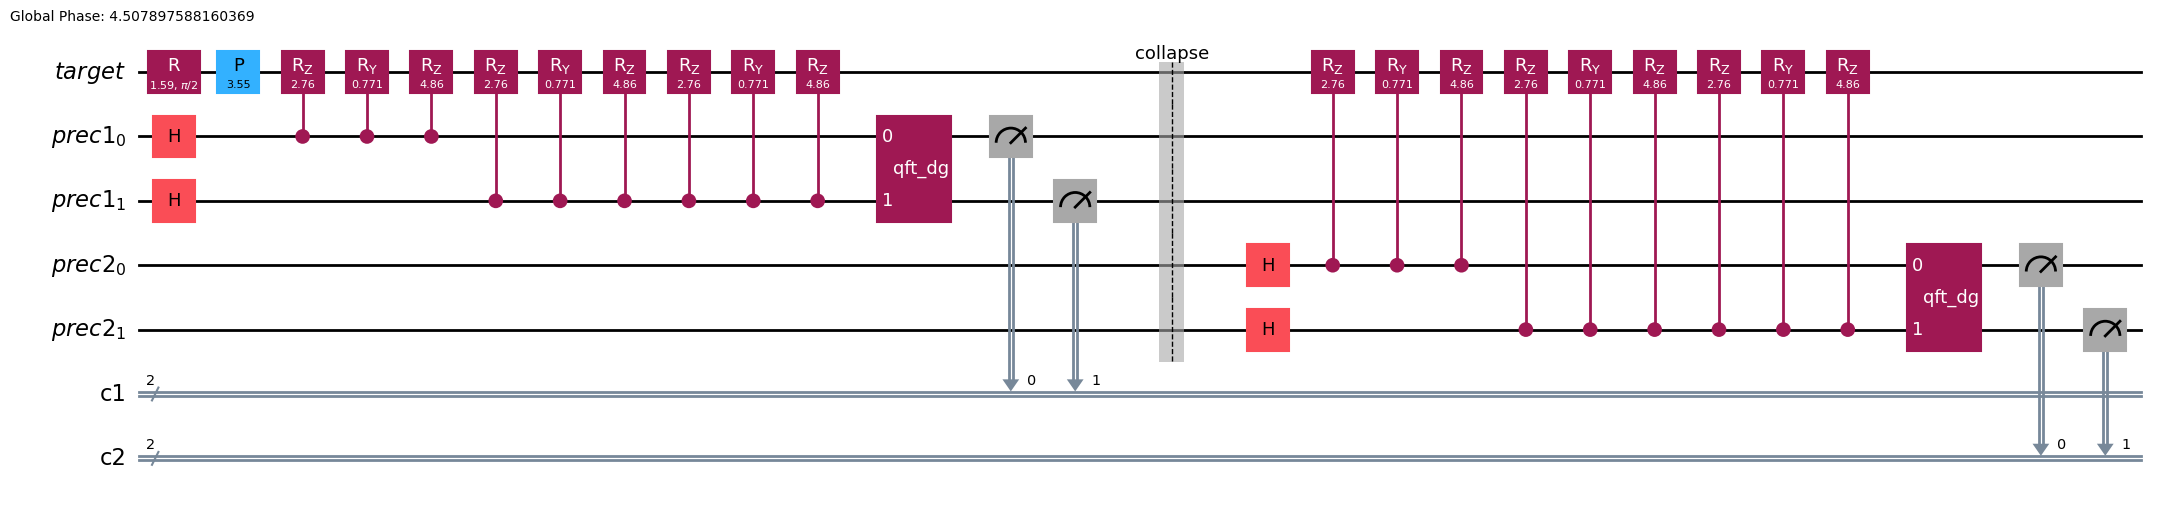

In [17]:
# ── Registers ─────────────────────────────────────────────────────────────
targ_reg  = QuantumRegister(n_targ, 'target')
prec1_reg = QuantumRegister(n_prec, 'prec1')
prec2_reg = QuantumRegister(n_prec, 'prec2')
c1        = ClassicalRegister(n_prec, 'c1')   # Stage-1 QPE outcome
c2        = ClassicalRegister(n_prec, 'c2')   # Stage-2 QPE outcome

qc = QuantumCircuit(targ_reg, prec1_reg, prec2_reg, c1, c2)

# ── Target: random single-qubit state ─────────────────────────────────────
init_rng   = np.random.default_rng(seed=99)
theta0, phi0 = init_rng.uniform(0, np.pi), init_rng.uniform(0, 2 * np.pi)
qc.ry(theta0, targ_reg[0])
qc.rz(phi0,   targ_reg[0])

# ── Stage 1: first QPE ────────────────────────────────────────────────────
qpe1 = build_qpe_circuit(n_prec, angles)   # angles from haar_random_1qubit_matrix
qc.append(qpe1, list(prec1_reg) + list(targ_reg))

# ── Mid-circuit measurement → collapses target onto an eigenstate of U ────
qc.measure(prec1_reg, c1)
qc.barrier(label='collapse')

# ── Stage 2: second QPE on the collapsed target ───────────────────────────
qpe2 = build_qpe_circuit(n_prec, angles)
qc.append(qpe2, list(prec2_reg) + list(targ_reg))

# ── Final measurement ─────────────────────────────────────────────────────
qc.measure(prec2_reg, c2)

total_qubits = qc.num_qubits
print(f'Total qubits   : {total_qubits}  (2×{n_prec} prec + {n_targ} target)')
print(f'Classical bits : {qc.num_clbits}')
print(f'IQM Garnet budget check: {"✓ OK (≤ 20)" if total_qubits <= 20 else "✗ Too many qubits"}')

# Gate count breakdown
ops = qc.decompose(reps=1).count_ops()
print(f'\nGate counts (1 decomp): {dict(ops)}')
total_crz = sum(2**k for k in range(n_prec)) * 2   # lam + phi per repetition, both stages x2
total_cry  = sum(2**k for k in range(n_prec))       # theta per repetition, both stages x2
print(f'Expected CRz gates (both stages): {total_crz * 2}  |  CRy: {total_cry * 2}')

qc.decompose(reps=1).draw(output='mpl', fold=80)

## Section A: Local Simulation

Run the circuit on `AerSimulator` — supports mid-circuit measurements natively.
Each shot independently:
1. Runs Stage-1 QPE, **measures** `prec1` → collapses `target` onto an eigenstate of U  
2. Runs Stage-2 QPE on the *same collapsed* `target`, measures `prec2`

Because the target is projected onto a phase eigenstate after Stage 1, both measurements track the same eigenvalue → `m1 ≈ m2` on every shot.

In [18]:
simulator  = AerSimulator()
transpiled = transpile(qc, simulator)
job        = simulator.run(transpiled, shots=n_shots)
result     = job.result()
counts     = result.get_counts()

print(f'Unique outcomes : {len(counts)}')

Unique outcomes : 16


In [19]:
# ── Acceptance rate ────────────────────────────────────────────────────────
total    = 0
accepted = 0

for outcome, count in counts.items():
    m1, m2 = parse_outcome(outcome, n_prec)
    dist   = cyclic_distance(m1, m2, n_prec)
    if dist <= delta:
        accepted += count
    total += count

acc_rate = accepted / total
print(f'Total shots        : {total}')
print(f'Accepted (dist ≤ {delta}) : {accepted}')
print(f'Acceptance rate    : {acc_rate:.4f}')

print('\nTop 10 outcomes:')
print(f'  {"bitstring":28s}  m1  m2  dist  count')
print(f'  {"-"*52}')
for k, v in sorted(counts.items(), key=lambda x: -x[1])[:10]:
    m1, m2 = parse_outcome(k, n_prec)
    print(f'  {k!r:28s}  {m1:3d}  {m2:3d}  {cyclic_distance(m1,m2,n_prec):4d}  {v}')

# Theoretical QPE bins for reference
print('\nTheoretical QPE bins (ideal):')
for ev in np.linalg.eigvals(unitary):
    phase = np.angle(ev) / (2 * np.pi)
    if phase < 0:
        phase += 1
    print(f'  phase={phase:.4f}  ideal bin={round(phase * 2**n_prec) % 2**n_prec}')

Total shots        : 1000
Accepted (dist ≤ 2) : 1000
Acceptance rate    : 1.0000

Top 10 outcomes:
  bitstring                     m1  m2  dist  count
  ----------------------------------------------------
  '10 10'                         2    2     0  205
  '11 10'                         2    3     1  133
  '10 11'                         3    2     1  131
  '11 11'                         3    3     0  121
  '01 10'                         2    1     1  92
  '10 01'                         1    2     1  78
  '01 01'                         1    1     0  55
  '10 00'                         0    2     2  35
  '01 11'                         3    1     2  31
  '00 10'                         2    0     2  29

Theoretical QPE bins (ideal):
  phase=0.3796  ideal bin=2
  phase=0.6204  ideal bin=2


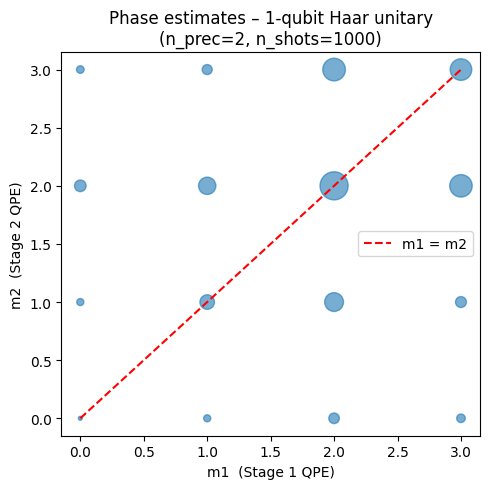

In [20]:
# ── Scatter: m1 vs m2 ─────────────────────────────────────────────────────
m1_vals, m2_vals, weights = [], [], []
for outcome, count in counts.items():
    m1, m2 = parse_outcome(outcome, n_prec)
    m1_vals.append(m1)
    m2_vals.append(m2)
    weights.append(count)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(m1_vals, m2_vals, s=np.array(weights) * 2.0, alpha=0.6)
ax.plot([0, 2**n_prec - 1], [0, 2**n_prec - 1], 'r--', label='m1 = m2')
ax.set_xlabel('m1  (Stage 1 QPE)')
ax.set_ylabel('m2  (Stage 2 QPE)')
ax.set_title(f'Phase estimates – 1-qubit Haar unitary\n(n_prec={n_prec}, n_shots={n_shots})')
ax.legend()
plt.tight_layout()
plt.show()

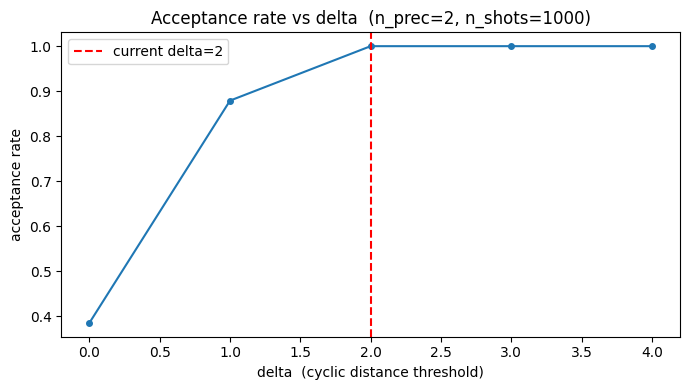


delta → acceptance rate
  delta=  0: 0.3850
  delta=  1: 0.8790
  delta=  2: 1.0000
  delta=  3: 1.0000
  delta=  4: 1.0000


In [21]:
# ── Acceptance rate vs delta sweep ─────────────────────────────────────────
delta_range = list(range(0, 2**n_prec + 1))
acc_rates   = []

for d in delta_range:
    acc = sum(
        count for outcome, count in counts.items()
        if cyclic_distance(*parse_outcome(outcome, n_prec), n_prec) <= d
    )
    acc_rates.append(acc / total)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(delta_range, acc_rates, marker='o', markersize=4)
ax.axvline(delta, color='r', linestyle='--', label=f'current delta={delta}')
ax.set_xlabel('delta  (cyclic distance threshold)')
ax.set_ylabel('acceptance rate')
ax.set_title(f'Acceptance rate vs delta  (n_prec={n_prec}, n_shots={n_shots})')
ax.legend()
plt.tight_layout()
plt.show()

print('\ndelta → acceptance rate')
for d, r in zip(delta_range[:10], acc_rates[:10]):
    print(f'  delta={d:3d}: {r:.4f}')

## Section B: Cost Estimation for IQM Garnet

Before submitting to hardware, we:
1. Decompose and transpile the circuit to IQM Garnet's native gate set (`prx`, `cz`)  
2. Inspect depth and 2-qubit gate count (dominant noise source)  
3. Estimate the Amazon Braket bill

IQM Garnet pricing (Amazon Braket): **$0.30/task + $0.00145/shot**

In [ ]:
# ── Cost estimation via a single QPE stage (no mid-circuit measurement) ────
# Transpiling the full two-stage circuit confuses the transpiler because
# optimization passes can move gates across the mid-circuit measurement
# boundary. Instead we transpile one QPE stage in isolation and scale by 2.

qpe_single = build_qpe_circuit(n_prec, angles)
qpe_single.measure_all()

iqm_basis      = ['r', 'rz', 'cz']
qpe_transpiled = transpile(qpe_single, basis_gates=iqm_basis, optimization_level=1)

ops   = qpe_transpiled.count_ops()
n_cz  = ops.get('cz', 0)
n_1q  = sum(v for k, v in ops.items() if k not in ('cz', 'measure', 'barrier'))
depth = qpe_transpiled.depth()

print('=== Single QPE stage — transpiled to IQM native gates (approx.) ===')
print(f'  CZ gates     : {n_cz:4d}   → both stages ≈ {n_cz*2}')
print(f'  1-qubit gates: {n_1q:4d}   → both stages ≈ {n_1q*2}')
print(f'  Depth        : {depth:4d}   → both stages ≈ {depth*2}')
print(f'  Qubits used (full circuit) : {qc.num_qubits}  (IQM Garnet has 20)')

# ── Amazon Braket pricing for IQM Garnet (as of early 2025) ───────────────
TASK_FEE = 0.30        # USD per task
SHOT_FEE = 0.00145     # USD per shot

print('\n=== Estimated cost on IQM Garnet ===')
print(f'  {"Shots":>6}   Task fee   Shot fee   Total')
print(f'  {"-"*45}')
for shots in [100, 250, 500, 1000, 2000]:
    total_cost = TASK_FEE + shots * SHOT_FEE
    print(f'  {shots:>6}    ${TASK_FEE:.2f}      ${shots * SHOT_FEE:.4f}     ${total_cost:.2f}')

print('\n⚠  Verify current pricing at https://aws.amazon.com/braket/pricing/')
print('   Each job = 1 task. Running the circuit multiple times = multiple tasks.')
print(f'\nRecommendation: start with 100 shots (${TASK_FEE + 100*SHOT_FEE:.2f}) to verify connectivity.')

## Section C: Run on IQM Garnet (AWS)

**Prerequisites**

| Step | What to do |
|------|-----------|
| AWS credentials | `aws configure` or attach an IAM role |
| Braket provider | `pip install qiskit-braket-provider` |
| S3 bucket | Create a bucket and set `S3_BUCKET` below |

**Device**: IQM Garnet – 20-qubit superconducting QPU (eu-north-1)  
**Native gate set**: `prx` (phased-X rotation), `cz`  
`qiskit-braket-provider` handles transpilation automatically.

> **Mid-circuit measurements**: IQM Garnet supports mid-circuit measurements
> via Amazon Braket. If a `DeviceOfflineException` is raised, check device
> availability at the [Amazon Braket console](https://console.aws.amazon.com/braket).

In [ ]:
session = AwsSession()
# Braket's default bucket follows the pattern: amazon-braket-{region}-{account-id}
bucket = session.default_bucket()
print(bucket)

In [ ]:
# ── Job configuration ─────────────────────────────────────────────────────
IQM_GARNET_ARN = "arn:aws:braket:eu-north-1::device/qpu/iqm/Garnet"
S3_BUCKET      = bucket   # ← replace with your bucket
S3_PREFIX      = "qpuf-iqm-garnet"
N_SHOTS_HW     = 500    # keep low for initial tests — see cost estimate above

In [ ]:
try:
    from qiskit_braket_provider import BraketProvider

    provider    = BraketProvider()
    iqm_backend = provider.get_backend("Garnet")

    print(f'Backend    : {iqm_backend.name}')
    print(f'Qubits     : {iqm_backend.num_qubits}')
    print(f'Basis gates: {iqm_backend.operation_names}')

    # Transpile for the real IQM backend
    qc_hw = transpile(qc, backend=iqm_backend, optimization_level=3)
    print(f'\nTranspiled depth : {qc_hw.depth()}')
    print(f'CZ gates         : {qc_hw.count_ops().get("cz", 0)}')

    # ── Submit ────────────────────────────────────────────────────────────
    # Uncomment to actually submit the job.
    # job_hw = iqm_backend.run(qc_hw, shots=N_SHOTS_HW)
    # print(f'\nJob submitted. ID: {job_hw.job_id()}')
    # print('Retrieve results with: job_hw.result() or retrieve_job(id)')

    print('\n[DRY RUN] Uncomment job_hw = iqm_backend.run(...) to submit.')

except ImportError:
    print('qiskit-braket-provider not installed.')
    print('Install with:  pip install qiskit-braket-provider')
except Exception as exc:
    print(f'Error: {exc}')

In [ ]:
# ── Retrieve results after the job completes ──────────────────────────────
# Replace YOUR-JOB-ID with the ID printed after submission.

# from qiskit_braket_provider import BraketProvider
#
# provider    = BraketProvider()
# iqm_backend = provider.get_backend("Garnet")
# job_hw      = iqm_backend.retrieve_job("YOUR-JOB-ID")
#
# counts_hw = job_hw.result().get_counts()
#
# total_hw    = sum(counts_hw.values())
# accepted_hw = sum(
#     count for outcome, count in counts_hw.items()
#     if cyclic_distance(*parse_outcome(outcome, n_prec), n_prec) <= delta
# )
# print(f'Hardware shots     : {total_hw}')
# print(f'Accepted (dist ≤ {delta}) : {accepted_hw}')
# print(f'Acceptance rate    : {accepted_hw / total_hw:.4f}')
#
# # Reuse the same plotting code from Section A with counts_hw instead of counts